C:\Users\suman\AppData\Local\Temp\ipykernel_27116\747505882.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=odor_counts.head(top_n).index, y=odor_counts.head(top_n).values, palette="viridis")


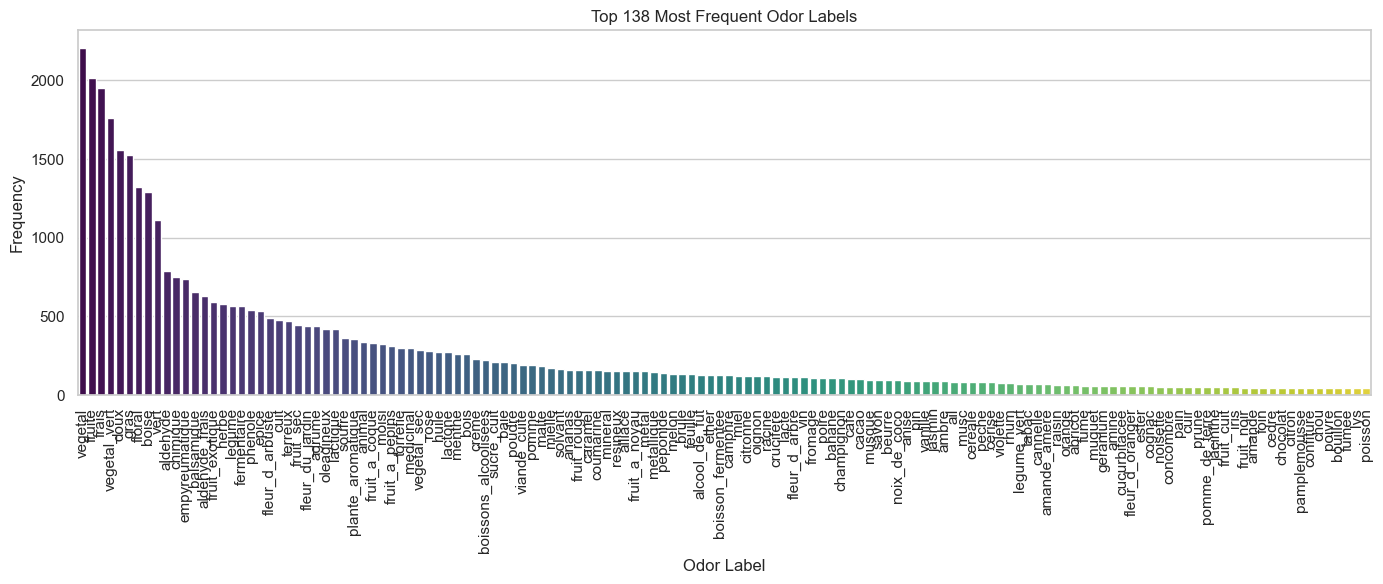

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\data\(Saturated)SoS_Full.csv")

# Exclude identifier and SMILES columns
odor_columns = df.columns[2:]

# Count how many times each odor descriptor appears
odor_counts = df[odor_columns].sum().sort_values(ascending=False)
odor_counts2 = df[odor_columns].sum().sort_values(ascending=True)

# Set Seaborn style
sns.set(style="whitegrid")

# Plot the histogram for top 50 odor labels
plt.figure(figsize=(14, 6))
top_n = 138
sns.barplot(x=odor_counts.head(top_n).index, y=odor_counts.head(top_n).values, palette="viridis")
plt.xticks(rotation=90)
plt.title(f"Top {top_n} Most Frequent Odor Labels")
plt.ylabel("Frequency")
plt.xlabel("Odor Label")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

# Load your dataset
df = pd.read_csv(r"C:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\data\(Saturated)SoS_Full.csv")

# Extract label columns
odor_labels = df.columns[2:]
odor_df = df[odor_labels]


C:\Users\suman\AppData\Local\Temp\ipykernel_27116\982838082.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=odor_counts.index[:50], y=odor_counts.values[:50], palette="mako")


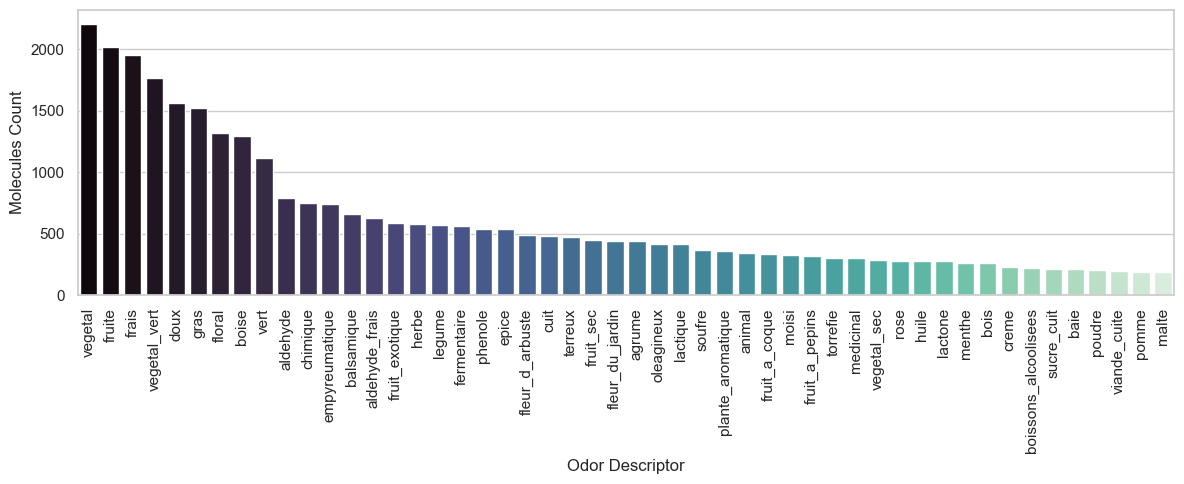

In [17]:
odor_counts = odor_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=odor_counts.index[:50], y=odor_counts.values[:50], palette="mako")
plt.xticks(rotation=90)
plt.ylabel("Molecules Count")
plt.xlabel("Odor Descriptor")
plt.tight_layout()
plt.show()


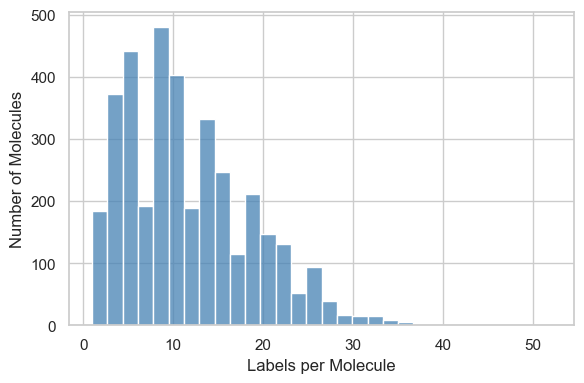

In [11]:
# Assuming `label_density` = number of labels per molecule
label_density = odor_df.sum(axis=1)

plt.figure(figsize=(6, 4))
sns.histplot(label_density, bins=30, kde=False, color="steelblue")
plt.xlabel("Labels per Molecule")
plt.ylabel("Number of Molecules")
plt.tight_layout()
plt.show()



c:\Users\suman\OneDrive\Bureau\Internship_Study\GNN_On_OdorPrediction\myenv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:310: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)


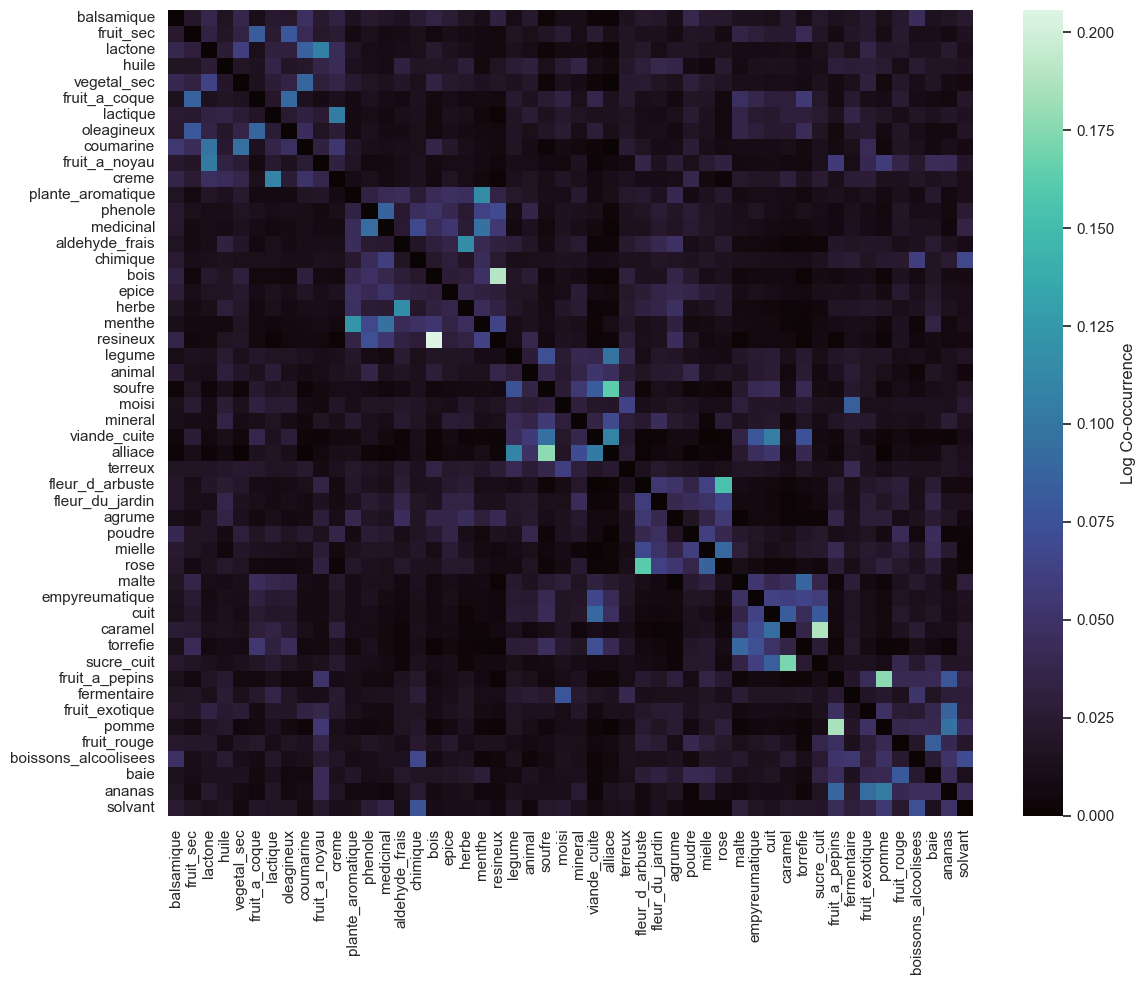

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.cluster import SpectralClustering

# Step 1: Remove top 10 most frequent descriptors
top10 = odor_counts.index[:10]
remaining_labels = [label for label in odor_labels if label not in top10]

# Step 2: Compute frequencies again to get top 50 of remaining
odor_counts_filtered = df[remaining_labels].sum().sort_values(ascending=False)
top50_labels = odor_counts_filtered.index[:50]

# Step 3: Build co-occurrence matrix for top 50
co_mat_50 = np.dot(df[top50_labels].T, df[top50_labels])
np.fill_diagonal(co_mat_50, 0)

# Step 4: Normalize rows and columns
co_mat_norm_50 = normalize(co_mat_50, axis=1, norm='l1')
co_mat_norm_50 = normalize(co_mat_norm_50.T, axis=1, norm='l1')

# Step 5: Spectral clustering to reorder
clustering = SpectralClustering(
    n_clusters=6,  # Feel free to adjust
    affinity='precomputed',
    assign_labels='discretize',
    random_state=42
)
cluster_labels = clustering.fit_predict(co_mat_norm_50)
sorted_idx = np.argsort(cluster_labels)
co_mat_sorted_50 = co_mat_norm_50[sorted_idx, :][:, sorted_idx]
sorted_labels = [top50_labels[i] for i in sorted_idx]

# Step 6: Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    np.log1p(co_mat_sorted_50),  # log1p for better contrast
    cmap="mako",
    xticklabels=sorted_labels,
    yticklabels=sorted_labels,
    cbar_kws={"label": "Log Co-occurrence"}
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
def imbalance_metrics(counts, label=""):
    max_count = counts.max()
    min_count = counts[counts > 0].min()
    ratio = max_count / min_count if min_count > 0 else float("inf")
    print(f"--- {label} ---")
    print(f"Total Labels: {len(counts)}")
    print(f"Max Count: {max_count}")
    print(f"Min Count (non-zero): {min_count}")
    print(f"Imbalance Ratio (Max/Min): {ratio:.2f}")
    print(f"Mean: {counts.mean():.2f}")
    print(f"Std Dev: {counts.std():.2f}")
    print()

imbalance_metrics(df_no_sat[odor_columns_no_sat].sum(), "Without Saturation")
imbalance_metrics(df_sat[odor_columns_sat].sum(), "With Saturation")


--- Without Saturation ---
Total Labels: 394
Max Count: 1220
Min Count (non-zero): 1
Imbalance Ratio (Max/Min): 1220.00
Mean: 49.99
Std Dev: 126.15

--- With Saturation ---
Total Labels: 436
Max Count: 2210
Min Count (non-zero): 1
Imbalance Ratio (Max/Min): 2210.00
Mean: 97.97
Std Dev: 261.82



In [7]:
# Count total odor descriptor columns (excluding cas_number and SMILES)
odor_columns_no_sat = df_no_sat.columns[2:]
odor_columns_sat = df_sat.columns[2:]

print("Odor Descriptors WITHOUT Saturation:", len(odor_columns_no_sat))
print("Odor Descriptors WITH Saturation:", len(odor_columns_sat))


Odor Descriptors WITHOUT Saturation: 394
Odor Descriptors WITH Saturation: 436


In [11]:
import pandas as pd

# Load your dataset
df = pd.read_csv('OdorSmiles_Updated.csv')

# Assume first two columns are 'cas_number' and 'SMILES'
label_df = df.iloc[:, 2:]

# Step 1: Sort descriptors by frequency
odor_freq = label_df.sum().sort_values(ascending=False)

# Step 2: Select the top 40 most frequent descriptors
top_n = 40
top_40_columns = odor_freq.head(top_n).index

# Step 3: Filter the original dataframe
label_df_filtered = label_df[top_40_columns]
df_filtered = pd.concat([df[['cas_number', 'SMILES']], label_df_filtered], axis=1)

# Step 4: Remove rows with zero labels
non_zero_labels = label_df_filtered.sum(axis=1)
filtered_df = df_filtered[non_zero_labels > 0]

# Step 5: Save and report
filtered_df.to_csv('top40_most_frequent_odors.csv', index=False)

# Print results
print(f"Top {top_n} most frequent odors selected.")
print(f"Rows in the new CSV: {filtered_df.shape[0]}")
print(f"Descriptors in new CSV: {label_df_filtered.shape[1]}")
print(f"Rows removed: {df.shape[0] - filtered_df.shape[0]}")

Top 40 most frequent odors selected.
Rows in the new CSV: 3692
Descriptors in new CSV: 40
Rows removed: 4
